1. INSTALL + DRIVE SETUP

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Removed explicit version for numpy as it caused an installation error and conflict
!pip install gensim
# Removed explicit version for jax to resolve incompatibility with jaxlib


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!pip uninstall -y jax jaxlib
!pip install jax==0.4.13 jaxlib==0.4.13

Found existing installation: jax 0.4.13
Uninstalling jax-0.4.13:
  Successfully uninstalled jax-0.4.13
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
  Using cached jax-0.4.13-py3-none-any.whl
ERROR: Ignored the following yanked versions: 0.4.32
ERROR: Could not find a version that satisfies the requirement jaxlib==0.4.13 (from versions: 0.4.18, 0.4.19, 0.4.20, 0.4.21, 0.4.22, 0.4.23, 0.4.24, 0.4.25, 0.4.26, 0.4.27, 0.4.28, 0.4.29, 0.4.30, 0.4.31, 0.4.33, 0.4.34, 0.4.35, 0.4.36, 0.4.38, 0.5.0, 0.5.1, 0.5.3, 0.6.0, 0.6.1, 0.6.2, 0.7.0, 0.7.1, 0.7.2, 0.8.0, 0.8.1, 0.8.2, 0.8.3, 0.9.0, 0.9.0.1, 0.9.1, 0.9.2, 0.10.0)
ERROR: No matching distribution found for jaxlib==0.4.13


2. IMPORT LIBRARIES

In [6]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

import gensim.downloader as api

3. NLTK SETUP

In [10]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

4. LOAD DATA

In [8]:
df = pd.read_csv('/content/drive/MyDrive/spamvsham.csv', encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


5. CLEAN TEXT

In [11]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    words = word_tokenize(text)

    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return " ".join(words)

df['cleaned'] = df['message'].apply(clean_text)

# Data Visualization

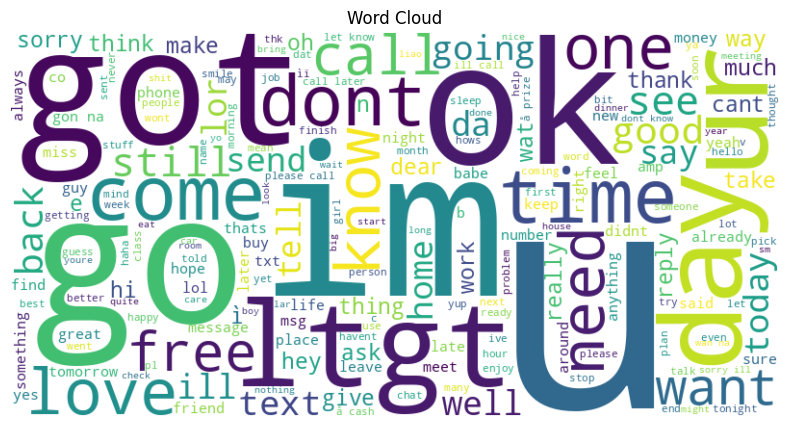

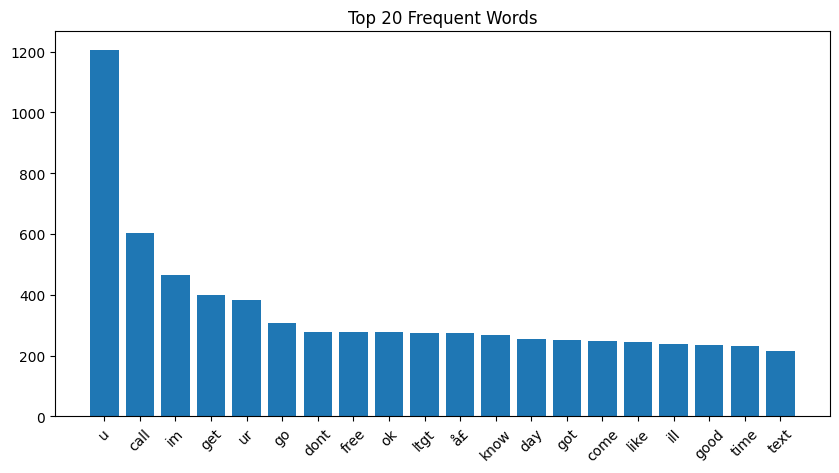

In [37]:
from collections import Counter
from wordcloud import WordCloud

all_words = " ".join(df['cleaned'])

# WordCloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white').generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

# Most frequent words
words = all_words.split()
common_words = Counter(words).most_common(20)

words_list = [word[0] for word in common_words]
count_list = [word[1] for word in common_words]

plt.figure(figsize=(10,5))
plt.bar(words_list, count_list)
plt.xticks(rotation=45)
plt.title("Top 20 Frequent Words")
plt.show()

6. TOKENIZATION

In [12]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['cleaned'])

seq = tokenizer.texts_to_sequences(df['cleaned'])

max_len = int(np.percentile([len(x) for x in seq], 95))

X = pad_sequences(seq, maxlen=max_len, padding='post')
y = df['label']

7. SPLIT DATA

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

8. VOCAB SIZE

In [14]:
vocab_size = len(tokenizer.word_index) + 1

9. EARLY STOPPING

In [15]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

MODEL 1 — RNN

In [39]:
model_rnn = Sequential([
    Embedding(vocab_size, 64),
    SimpleRNN(64, dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [40]:
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9344 - loss: 0.1912 - val_accuracy: 0.9608 - val_loss: 0.1218
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9879 - loss: 0.0568 - val_accuracy: 0.9652 - val_loss: 0.1376


MODEL 2 — LSTM

In [22]:
model_lstm = Sequential([
    Embedding(vocab_size, 128),
    LSTM(64, dropout=0.3),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [41]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.9989 - loss: 0.0090 - val_accuracy: 0.9574 - val_loss: 0.2097
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9955 - loss: 0.0232 - val_accuracy: 0.9675 - val_loss: 0.1675


MODEL 3 — WORD2VEC + LSTM

In [27]:
embedding_model = api.load('glove-wiki-gigaword-50')
embedding_dim = 50

In [28]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

In [29]:
model_w2v = Sequential([
    Embedding(
        vocab_size,
        embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    ),
    LSTM(64),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model_w2v.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [42]:
history_w2v = model_w2v.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9607 - loss: 0.1221 - val_accuracy: 0.9574 - val_loss: 0.1305
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9691 - loss: 0.1048 - val_accuracy: 0.9574 - val_loss: 0.1198


# Training vs Validation Graphs

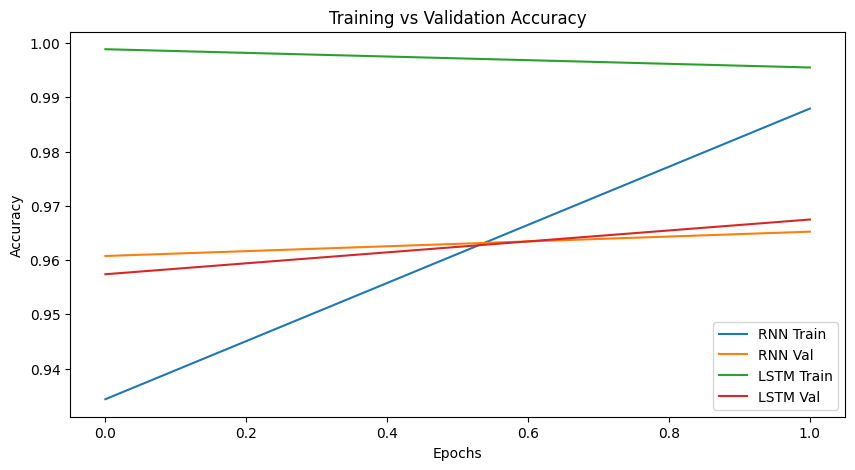

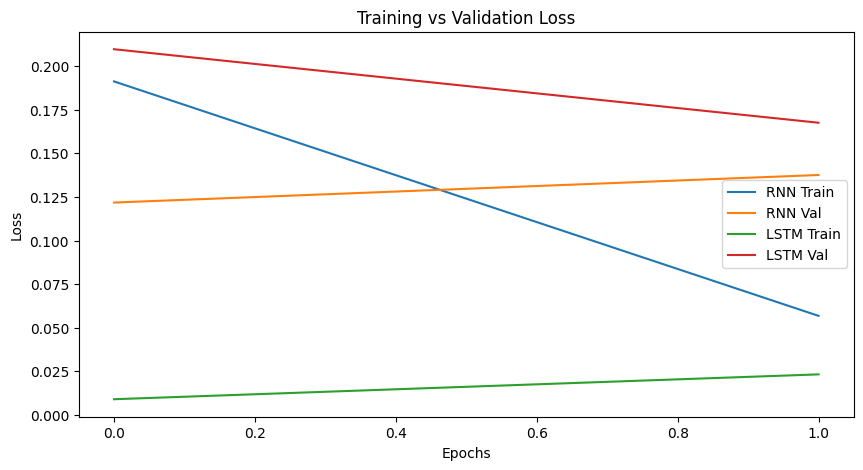

In [43]:
# Accuracy Plot
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['accuracy'], label='RNN Train')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Val')

plt.plot(history_lstm.history['accuracy'], label='LSTM Train')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val')

plt.legend()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()


# Loss Plot
plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'], label='RNN Train')
plt.plot(history_rnn.history['val_loss'], label='RNN Val')

plt.plot(history_lstm.history['loss'], label='LSTM Train')
plt.plot(history_lstm.history['val_loss'], label='LSTM Val')

plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

EVALUATION

In [31]:
def evaluate(model, name):
    pred = (model.predict(X_test) > 0.5).astype(int)

    print("\n", name)
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name)
    plt.show()

    return accuracy_score(y_test, pred)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

 RNN
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



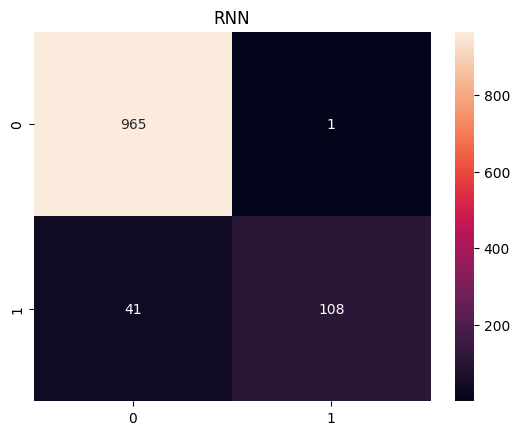

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

 LSTM
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       0.98      0.84      0.90       149

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.94      1115
weighted avg       0.98      0.98      0.97      1115



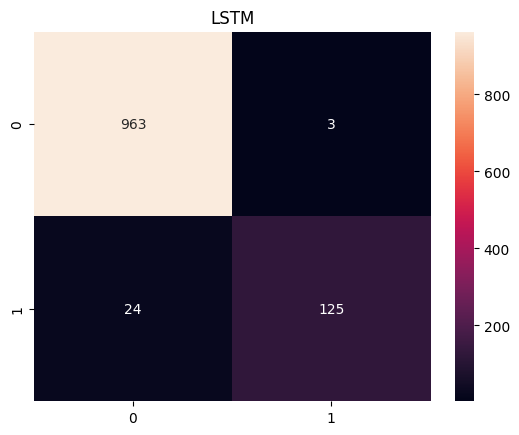

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

 LSTM + W2V
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       966
           1       0.78      0.83      0.80       149

    accuracy                           0.95      1115
   macro avg       0.88      0.89      0.88      1115
weighted avg       0.95      0.95      0.95      1115



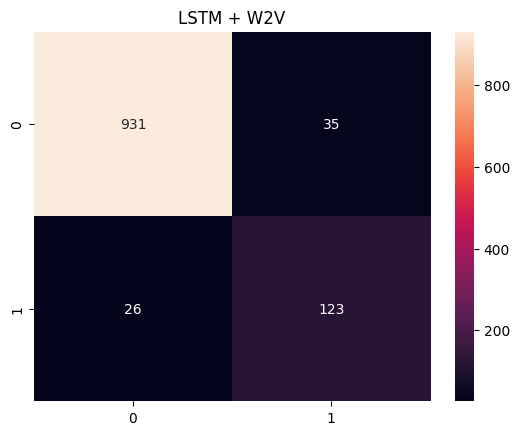

In [32]:
rnn_acc = evaluate(model_rnn, "RNN")
lstm_acc = evaluate(model_lstm, "LSTM")
w2v_acc = evaluate(model_w2v, "LSTM + W2V")

# Confusion Matrix

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


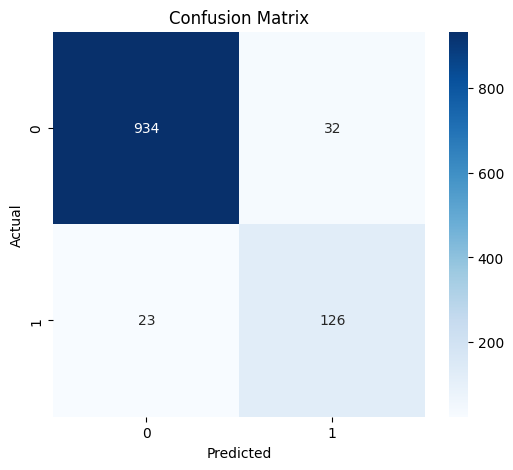

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = (model_lstm.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Error Analysis

In [46]:
predictions = (model_lstm.predict(X_test) > 0.5).astype("int32")

for i in range(len(predictions)):
    if predictions[i] != y_test.iloc[i]:
        print("Tweet:", df.iloc[i]['cleaned'])
        print("Actual:", y_test.iloc[i])
        print("Predicted:", predictions[i][0])
        print("-"*50)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Tweet: forget tell want need crave love sweet arabian steed mmmmmm yummy
Actual: 0
Predicted: 1
--------------------------------------------------
Tweet: great hope like man well endowed ltgt inch
Actual: 1
Predicted: 0
--------------------------------------------------
Tweet: congrats year special cinema pas call c suprman v matrix starwars etc free bxipwe pm dont miss
Actual: 0
Predicted: 1
--------------------------------------------------
Tweet: finished class
Actual: 0
Predicted: 1
--------------------------------------------------
Tweet: sorry pain ok meet another night spent late afternoon casualty mean havent done stuffmoro includes time sheet sorry
Actual: 0
Predicted: 1
--------------------------------------------------
Tweet: going sao mu today done
Actual: 1
Predicted: 0
--------------------------------------------------
Tweet: haf msn yijuecom
Actual: 0
Predicted: 1
--------------------------------------------------
Tweet: yes see ya

COMPARISON

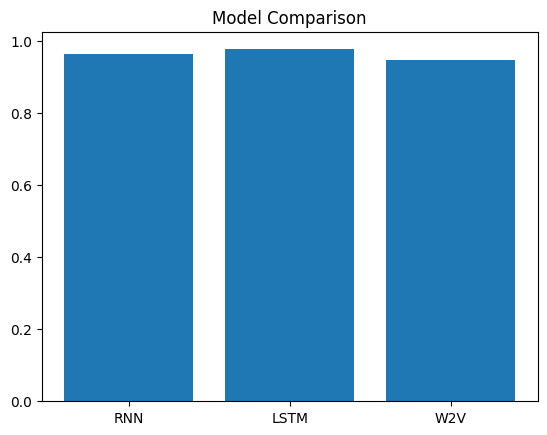

In [33]:
plt.bar(['RNN','LSTM','W2V'], [rnn_acc,lstm_acc,w2v_acc])
plt.title("Model Comparison")
plt.show()

PREDICTION FUNCTION

In [34]:
def predict(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding='post')

    pred = model_lstm.predict(pad)[0][0]

    return "Spam" if pred > 0.5 else "Ham"

Test

In [35]:
predict("You won a free iPhone click now")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


'Ham'

# Real Time Prediction GUI

In [47]:
!pip install gradio

import gradio as gr

def predict_sentiment(text):

    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)

    prediction = model_lstm.predict(padded)[0][0]

    if prediction > 0.5:
        return "Positive"
    else:
        return "Negative"

iface = gr.Interface(
    fn=predict_sentiment,
    inputs="text",
    outputs="text",
    title="Sentiment Analysis"
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://587924d93e87bd1d67.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
